# 06 - Explainability for Late Fusion Architecture

This notebook explains the Late Fusion model by:
1. Loading both genomic and clinical models separately
2. Computing feature importance for each branch
3. Combining importances using fusion weights
4. Generating SHAP analysis for both branches

In [5]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import config
from src.io import load_model, save_figure, save_table, logger
from src.models import xgb_safe_frame, xgb_feature_name_map
from src.clinical_engineer import create_clinical_features, get_clinical_feature_names
from src.genomic_engineer import create_genomic_pathway_features
from src.visualization import setup_style

setup_style()

## Step 1: Load Models and Data

In [2]:
print("Loading Late Fusion models...")

# Load individual branch models
genomic_model = load_model("genomic_model.joblib")
clinical_model = load_model("clinical_model.joblib")

# Load Late Fusion predictor
fusion_predictor = load_model("late_fusion_predictor.joblib")

print(f"Genomic model loaded: {type(genomic_model).__name__}")
print(f"Clinical model loaded: {type(clinical_model).__name__}")
print(f"Fusion weights: genomic={fusion_predictor.genomic_weight:.3f}, clinical={fusion_predictor.clinical_weight:.3f}")

2026-09-14 22:30:07 | INFO     | prostate_bcr | Loading model from D:\Prostate_BCR\core\outputs\models\genomic_model.joblib


Loading Late Fusion models...


2026-09-14 22:30:09 | INFO     | prostate_bcr | Loading model from D:\Prostate_BCR\core\outputs\models\clinical_model.joblib
2026-09-14 22:30:09 | INFO     | prostate_bcr | Loading model from D:\Prostate_BCR\core\outputs\models\late_fusion_predictor.joblib


Genomic model loaded: XGBClassifier
Clinical model loaded: XGBClassifier
Fusion weights: genomic=0.380, clinical=0.620


In [6]:
# Load test data
X_test_raw = pd.read_csv(config.PROCESSED_DIR / "X_test_preprocessed.csv")
y_test = pd.read_csv(config.PROCESSED_DIR / "y_test.csv").iloc[:, 0]

# Load selected feature lists
genomic_features_df = pd.read_csv(config.TABLES_DIR / "final_genomic_features.csv")
genomic_features = genomic_features_df["feature"].tolist()

clinical_features_df = pd.read_csv(config.TABLES_DIR / "final_clinical_features.csv")
clinical_features = clinical_features_df["feature"].tolist()

print(f"Genomic features: {len(genomic_features)}")
print(f"Clinical features: {len(clinical_features)}")

# Prepare genomic branch data, including pathway scores used during training
X_test_genomic, genomic_engineered_features = create_genomic_pathway_features(X_test_raw)
missing_genomic_features = sorted(set(genomic_features) - set(X_test_genomic.columns))
if missing_genomic_features:
    raise KeyError(f"Missing genomic features after engineering: {missing_genomic_features}")
X_test_genomic = X_test_genomic[genomic_features].copy()

# Prepare clinical branch data
X_test_clinical, _ = create_clinical_features(X_test_raw)
missing_clinical_features = sorted(set(clinical_features) - set(X_test_clinical.columns))
if missing_clinical_features:
    raise KeyError(f"Missing clinical features after engineering: {missing_clinical_features}")
X_test_clinical = X_test_clinical[clinical_features].copy()

print(f"Test samples: {X_test_genomic.shape[0]}")

2026-09-14 22:50:32 | INFO     | prostate_bcr | Genomic: PSA_Pathway_Score (from 7 genes)
2026-09-14 22:50:32 | INFO     | prostate_bcr | Genomic: AR_Signaling_Score (from 8 genes)
2026-09-14 22:50:32 | INFO     | prostate_bcr | Genomic: Proliferation_Score (from 7 genes)


Genomic features: 43
Clinical features: 40


2026-09-14 22:50:32 | INFO     | prostate_bcr | Clinical: Gleason_Total, High_Risk_Gleason
2026-09-14 22:50:32 | INFO     | prostate_bcr | Clinical: Margin_x_LymphNode
2026-09-14 22:50:32 | INFO     | prostate_bcr | Clinical: T_Stage_Risk


Test samples: 86


## Step 2: Feature Importance Analysis

In [7]:
# Get combined feature importance from Late Fusion
importance_df = fusion_predictor.get_feature_importance(
    genomic_features=genomic_features,
    clinical_features=clinical_features,
)

print("Top 20 Features by Combined Importance:")
print(importance_df.head(20).to_string(index=False))

Top 20 Features by Combined Importance:
                                                                                           feature  importance   branch
                                                                 Person Neoplasm Status_WITH TUMOR    0.077106 clinical
                                                                                      T_Stage_Risk    0.036453 clinical
                                                                        Gleason pattern tertiary_3    0.028685 clinical
                                   Primary Therapy Outcome Success Type_Partial Remission/Response    0.027599 clinical
                                                                     Year Cancer Initial Diagnosis    0.024887 clinical
                      Neoplasm Disease Lymph Node Stage American Joint Committee on Cancer Code_N1    0.023409 clinical
                                                                                              CTRC    0.023064  genomic


2026-09-14 22:51:31 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\late_fusion_feature_importance_top20.png


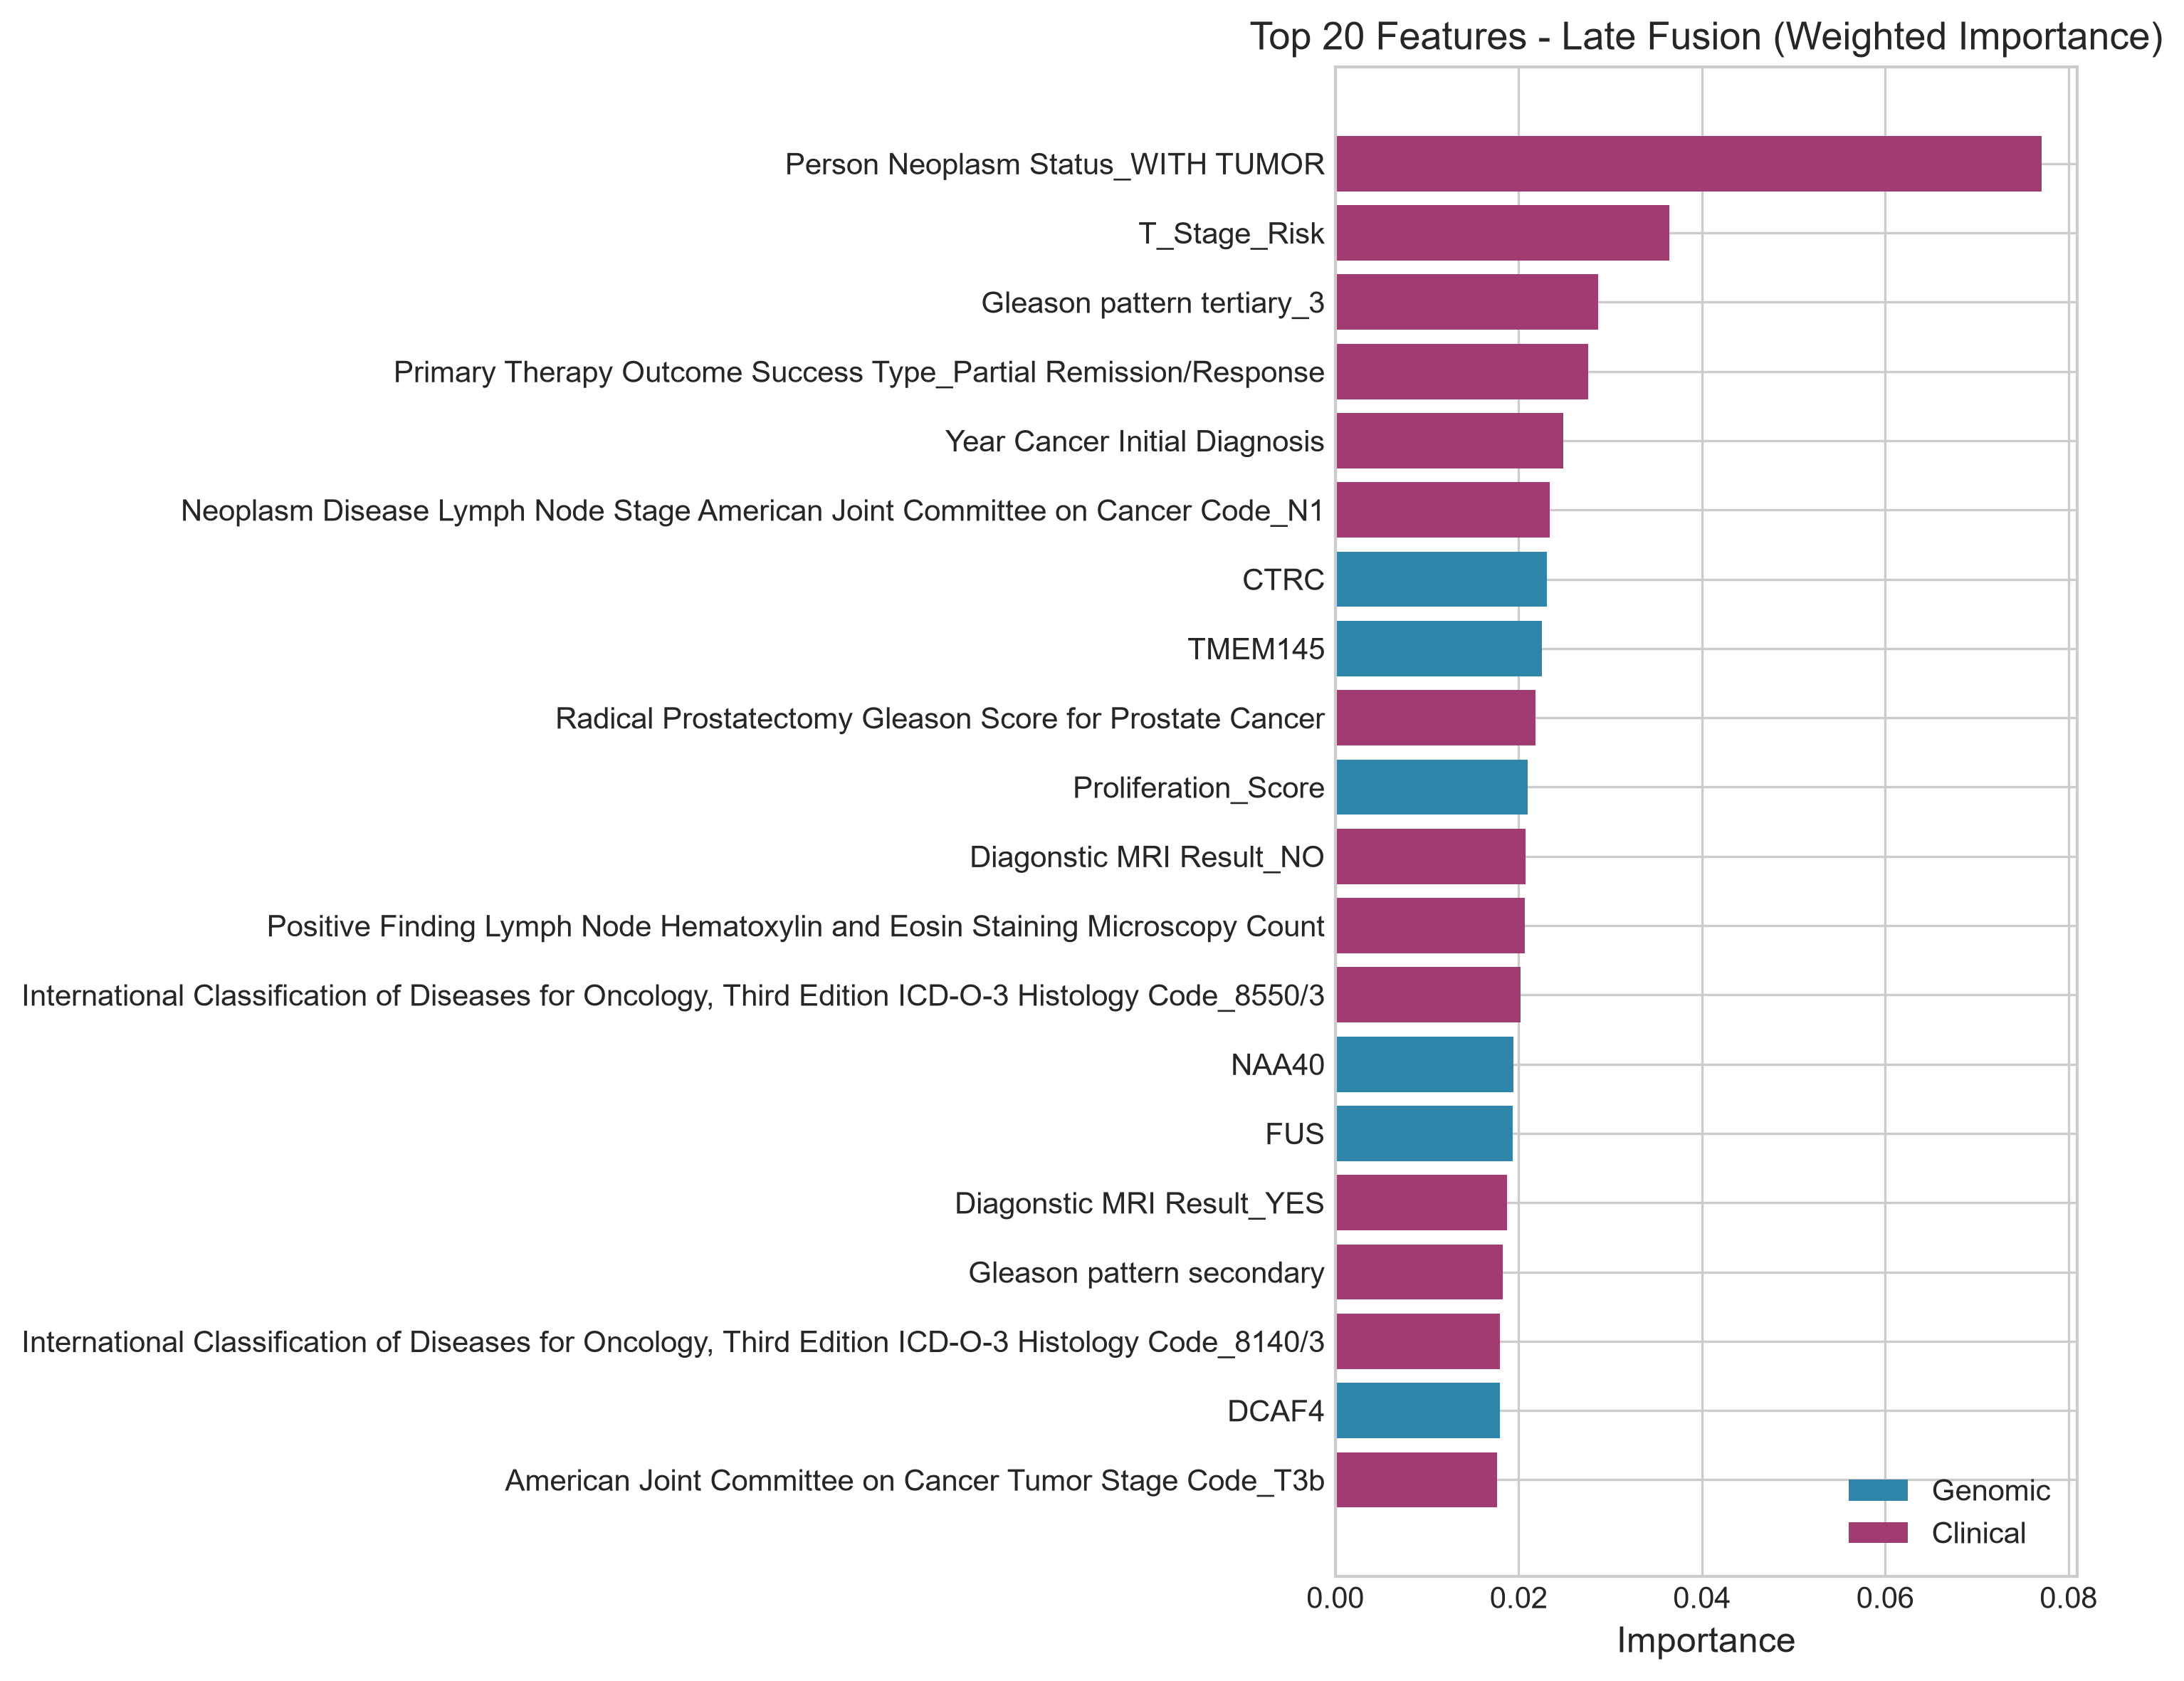

In [8]:
# Plot top 20 features
fig, ax = plt.subplots(figsize=(10, 8))

top_20 = importance_df.head(20)
colors = ['#2E86AB' if b == 'genomic' else '#A23B72' for b in top_20['branch']]

ax.barh(range(len(top_20)), top_20['importance'].values, color=colors)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Top 20 Features - Late Fusion (Weighted Importance)')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', label='Genomic'),
    Patch(facecolor='#A23B72', label='Clinical')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
save_figure(fig, "late_fusion_feature_importance_top20.png")
plt.show()

## Step 3: Separate Branch Importances

In [9]:
# Helper to extract importance from model
def extract_importance(model):
    if hasattr(model, 'named_steps'):
        for step_name, step_model in model.named_steps.items():
            if hasattr(step_model, 'feature_importances_'):
                return step_model.feature_importances_
    elif hasattr(model, 'feature_importances_'):
        return model.feature_importances_
    return None

# Genomic branch importance
genomic_imp = extract_importance(genomic_model)
if genomic_imp is not None:
    genomic_imp_df = pd.DataFrame({
        'feature': genomic_features,
        'importance': genomic_imp
    }).sort_values('importance', ascending=False)
    print("\nTop 10 Genomic Features:")
    print(genomic_imp_df.head(10).to_string(index=False))

# Clinical branch importance
clinical_imp = extract_importance(clinical_model)
if clinical_imp is not None:
    clinical_imp_df = pd.DataFrame({
        'feature': clinical_features,
        'importance': clinical_imp
    }).sort_values('importance', ascending=False)
    print("\nTop 10 Clinical Features:")
    print(clinical_imp_df.head(10).to_string(index=False))


Top 10 Genomic Features:
            feature  importance
               CTRC    0.060696
            TMEM145    0.059355
Proliferation_Score    0.055309
              NAA40    0.051227
                FUS    0.050992
              DCAF4    0.047252
             RASSF2    0.044791
               ASPA    0.040963
              BCRP3    0.038736
              RACH1    0.034228

Top 10 Clinical Features:
                                                                                           feature  importance
                                                                 Person Neoplasm Status_WITH TUMOR    0.124364
                                                                                      T_Stage_Risk    0.058796
                                                                        Gleason pattern tertiary_3    0.046266
                                   Primary Therapy Outcome Success Type_Partial Remission/Response    0.044515
                                        

2026-09-14 22:51:56 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\branch_comparison_importance.png


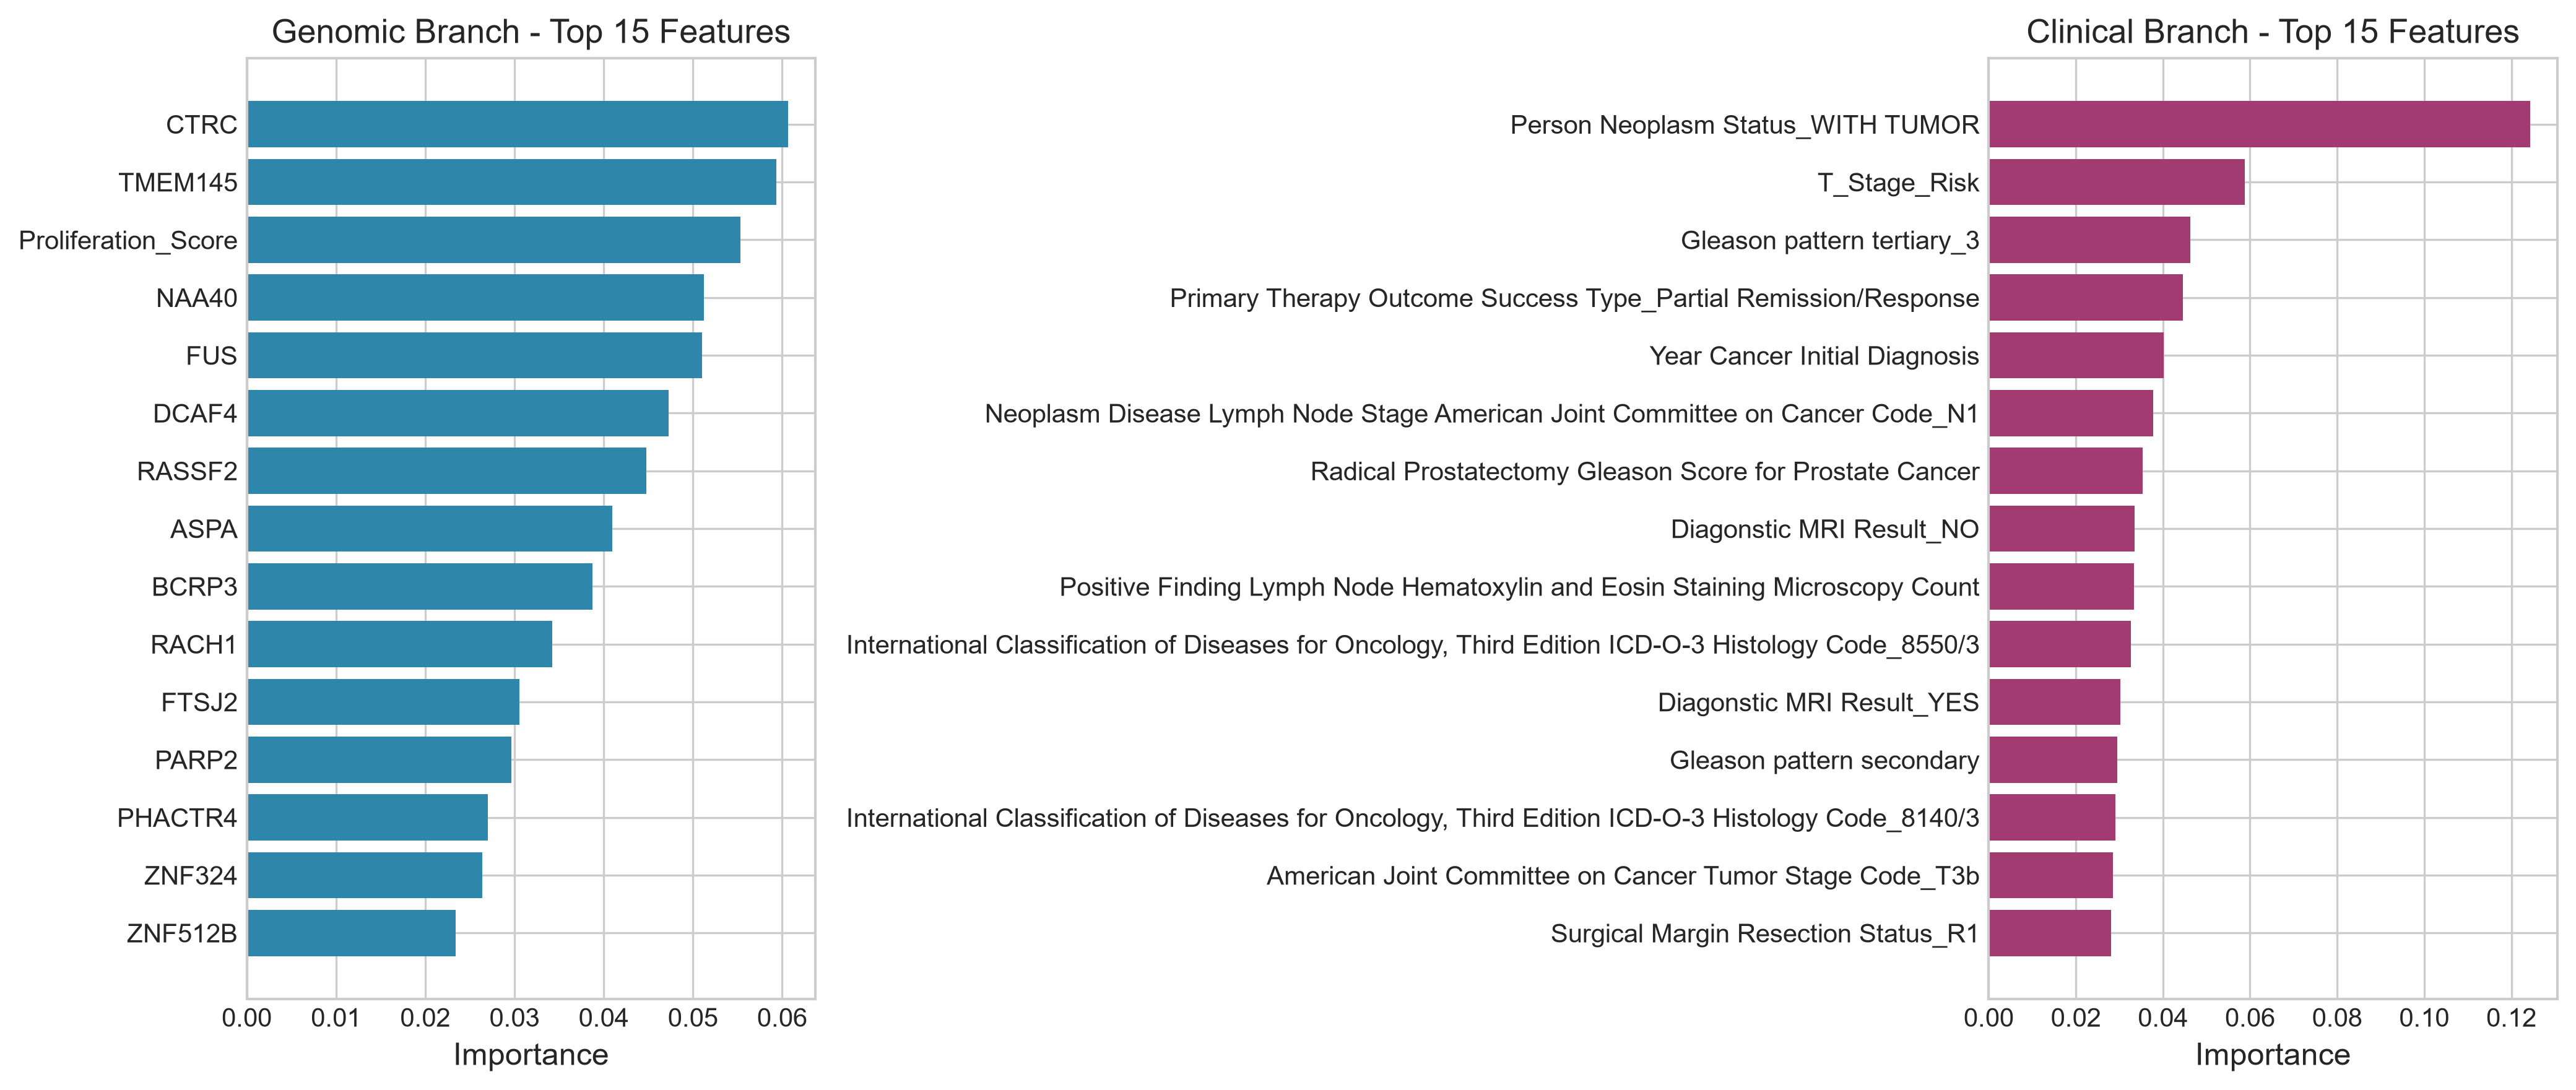

In [10]:
# Plot side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Genomic
if genomic_imp is not None:
    top_genomic = genomic_imp_df.head(15)
    axes[0].barh(range(len(top_genomic)), top_genomic['importance'].values, color='#2E86AB')
    axes[0].set_yticks(range(len(top_genomic)))
    axes[0].set_yticklabels(top_genomic['feature'].values)
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Importance')
    axes[0].set_title('Genomic Branch - Top 15 Features')

# Clinical
if clinical_imp is not None:
    top_clinical = clinical_imp_df.head(15)
    axes[1].barh(range(len(top_clinical)), top_clinical['importance'].values, color='#A23B72')
    axes[1].set_yticks(range(len(top_clinical)))
    axes[1].set_yticklabels(top_clinical['feature'].values)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Clinical Branch - Top 15 Features')

plt.tight_layout()
save_figure(fig, "branch_comparison_importance.png")
plt.show()

## Step 4: SHAP Analysis

d:\Prostate_BCR\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP library available. Running SHAP analysis...

Computing SHAP values for genomic model...


2026-09-14 22:52:06 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\shap_genomic_summary.png


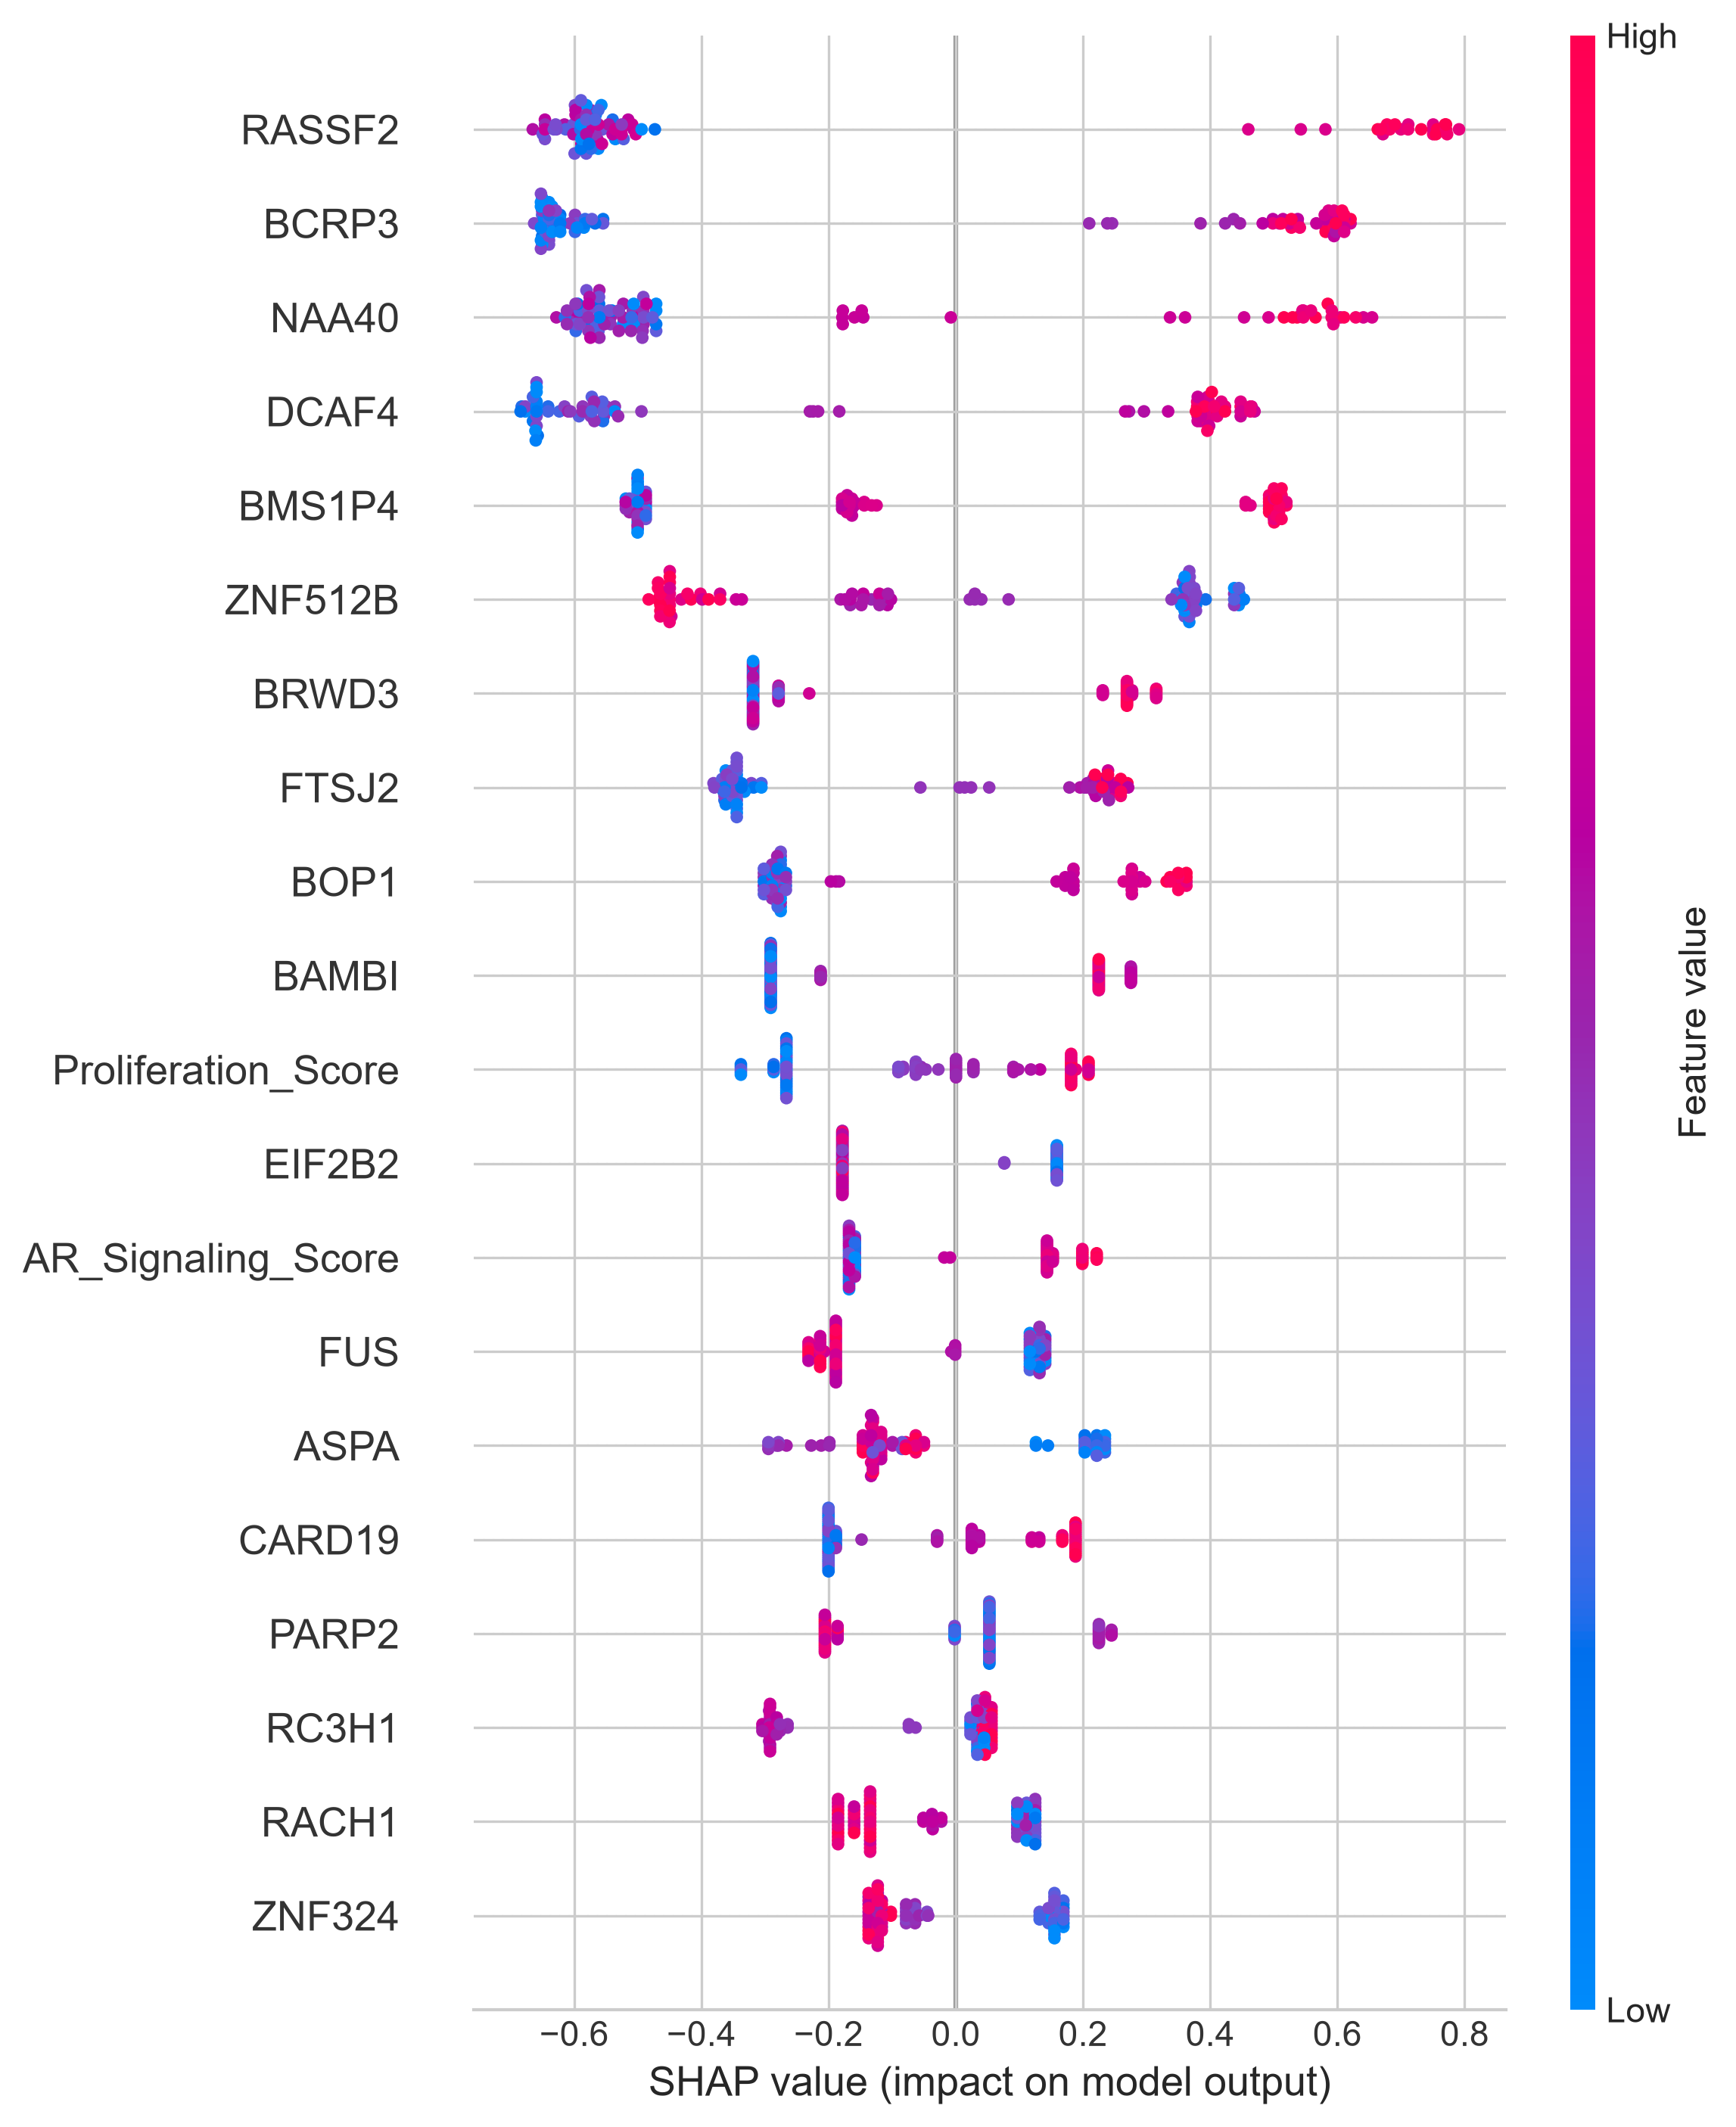


Computing SHAP values for clinical model...
SHAP analysis error: feature_names must be string, and may not contain [, ] or <


In [11]:
try:
    import shap
    print("SHAP library available. Running SHAP analysis...")
    
    # SHAP for genomic model
    print("\nComputing SHAP values for genomic model...")
    X_test_genomic_safe = xgb_safe_frame(X_test_genomic)
    
    # Create SHAP explainer for genomic model
    explainer_genomic = shap.TreeExplainer(genomic_model)
    shap_values_genomic = explainer_genomic.shap_values(X_test_genomic_safe)
    
    # SHAP summary plot for genomic
    fig = plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_genomic, X_test_genomic_safe, max_display=20, show=False)
    save_figure(fig, "shap_genomic_summary.png")
    plt.show()
    
    # SHAP for clinical model
    print("\nComputing SHAP values for clinical model...")
    explainer_clinical = shap.TreeExplainer(clinical_model)
    shap_values_clinical = explainer_clinical.shap_values(X_test_clinical)
    
    # SHAP summary plot for clinical
    fig = plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_clinical, X_test_clinical, max_display=20, show=False)
    save_figure(fig, "shap_clinical_summary.png")
    plt.show()
    
    print("SHAP analysis completed successfully.")
    
except ImportError:
    print("SHAP library not available. Install with: pip install shap")
except Exception as e:
    print(f"SHAP analysis error: {e}")

## Step 5: Save Results

In [ ]:
# Save full importance rankings
save_table(importance_df, "late_fusion_feature_importance_full.csv", index=False)

if genomic_imp is not None:
    save_table(genomic_imp_df, "genomic_branch_importance_full.csv", index=False)

if clinical_imp is not None:
    save_table(clinical_imp_df, "clinical_branch_importance_full.csv", index=False)

print("Results saved to outputs/tables/")

2026-09-14 14:16:19 | INFO     | prostate_bcr | Saved 158 rows → D:\Prostate_BCR\core\outputs\tables\late_fusion_feature_importance_full.csv
2026-09-14 14:16:19 | INFO     | prostate_bcr | Saved 40 rows → D:\Prostate_BCR\core\outputs\tables\genomic_branch_importance_full.csv
2026-09-14 14:16:19 | INFO     | prostate_bcr | Saved 118 rows → D:\Prostate_BCR\core\outputs\tables\clinical_branch_importance_full.csv


Results saved to outputs/tables/
